# 下一课：CartPole + Rainbow-lite

这一课我们把前面学过的几个经典改进组合起来，做一个轻量版的 `Rainbow` 风格 DQN：

- `Double DQN`
- `Dueling DQN`
- `Prioritized Experience Replay`

这还不是完整论文版 Rainbow，但已经非常适合教学和理解主线。

这一课你会学到：
- 为什么这些技巧可以组合在一起
- 组合后代码里到底改了哪几块
- 一个更完整的 DQN 体系长什么样


## 1. 这节课到底在组合什么

到目前为止，你已经分别学过：

- `Double DQN`：减少 Q 值高估
- `Dueling DQN`：把状态价值和动作优势拆开学
- `Prioritized Replay`：优先学习更值得学的经验

它们关注的问题并不冲突：
- 一个改 target 计算
- 一个改网络结构
- 一个改经验采样方式

所以它们非常适合组合起来一起用。


## 2. 这节课的重点不是“更复杂”，而是“更完整”

这一课最值得体会的地方是：

- 一个 RL 算法并不总是只靠一个点子变强
- 很多时候是多个互补的小改进叠起来，整体效果才更好

所以这节课你不需要死记所有细节，而是要看懂：

**每个模块分别负责解决什么问题。**


In [1]:
import random
import warnings

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [2]:
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.zeros(1, device='cuda')
            return torch.device('cuda')
        except Exception as e:
            warnings.warn(f'检测到 CUDA，但当前环境无法真正使用 GPU，已回退到 CPU。原因: {e}')
    return torch.device('cpu')


device = pick_device()
print('当前设备:', device)
if torch.cuda.is_available():
    print('检测到 CUDA 设备:', torch.cuda.get_device_name(0))


当前设备: cuda
检测到 CUDA 设备: NVIDIA GeForce RTX 5090


In [3]:
env = gym.make('CartPole-v1')
state, info = env.reset(seed=42)
print('初始状态:', state)
print('状态维度:', env.observation_space.shape[0])
print('动作数量:', env.action_space.n)


初始状态: [ 0.027 -0.006  0.036  0.02 ]
状态维度: 4
动作数量: 2


In [4]:
def to_tensor(x, device):
    return torch.tensor(x, dtype=torch.float32, device=device)


## 3. Dueling 网络结构

这次我们的网络使用 Dueling 结构：

- 共享特征提取层
- `value_stream` 学 `V(s)`
- `advantage_stream` 学 `A(s, a)`
- 最后组合回 `Q(s, a)`


In [5]:
class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()

        self.feature = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        features = self.feature(x)
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


## 4. Prioritized Replay Buffer

经验池这次使用 PER：
- TD error 越大的样本
- 被抽中的概率越高

这里我们继续沿用教学版实现，让主线保持清晰。


In [6]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity=50000, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = []
        self.priorities = []
        self.pos = 0

    def push(self, state, action, reward, next_state, done):
        max_priority = max(self.priorities, default=1.0)
        transition = (state, action, reward, next_state, done)

        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
            self.priorities.append(max_priority)
        else:
            self.buffer[self.pos] = transition
            self.priorities[self.pos] = max_priority
            self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        priorities = np.array(self.priorities, dtype=np.float32)
        scaled_priorities = priorities ** self.alpha
        probs = scaled_priorities / scaled_priorities.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probs, replace=False)
        batch = [self.buffer[idx] for idx in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), actions, rewards, np.array(next_states), dones, indices

    def update_priorities(self, indices, td_errors, eps=1e-5):
        for idx, td_error in zip(indices, td_errors):
            self.priorities[idx] = float(abs(td_error) + eps)

    def __len__(self):
        return len(self.buffer)


## 5. 训练 Rainbow-lite

这部分就是整节课的核心整合：

- 网络结构用 `Dueling DQN`
- target 计算用 `Double DQN`
- 经验池采样用 `Prioritized Replay`

你可以一边读代码，一边对应这三件事分别在哪几行出现。


In [7]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = DuelingQNetwork(state_dim, action_dim, hidden_dim=128).to(device)
target_net = DuelingQNetwork(state_dim, action_dim, hidden_dim=128).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=5e-4)
criterion = nn.SmoothL1Loss(reduction='none')
replay_buffer = PrioritizedReplayBuffer(capacity=50000, alpha=0.6)

gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.997
epsilon_min = 0.02
episodes = 300
max_steps = 500
batch_size = 128
target_update_freq = 20
train_start = 1000

episode_rewards = []
loss_history = []
buffer_sizes = []
priority_means = []

for episode in range(episodes):
    state, info = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        state_tensor = to_tensor(state, device).unsqueeze(0)

        with torch.no_grad():
            q_values = q_net(state_tensor)

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(torch.argmax(q_values, dim=1).item())

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        buffer_sizes.append(len(replay_buffer))
        priority_means.append(float(np.mean(replay_buffer.priorities)))

        state = next_state
        total_reward += reward

        if len(replay_buffer) >= train_start:
            states, actions, rewards, next_states, dones, indices = replay_buffer.sample(batch_size)

            states_tensor = to_tensor(states, device)
            next_states_tensor = to_tensor(next_states, device)
            actions_tensor = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
            rewards_tensor = torch.tensor(rewards, dtype=torch.float32, device=device)
            dones_tensor = torch.tensor(dones, dtype=torch.float32, device=device)

            # Dueling 网络输出当前 Q 值
            current_q_values = q_net(states_tensor)
            chosen_q_values = current_q_values.gather(1, actions_tensor).squeeze(1)

            with torch.no_grad():
                # Double DQN：主网络选动作
                next_actions = q_net(next_states_tensor).argmax(dim=1, keepdim=True)

                # Double DQN：目标网络给这个动作打分
                next_q_values_target = target_net(next_states_tensor)
                selected_next_q_values = next_q_values_target.gather(1, next_actions).squeeze(1)

                targets = rewards_tensor + gamma * selected_next_q_values * (1 - dones_tensor)

            per_sample_loss = criterion(chosen_q_values, targets)
            loss = per_sample_loss.mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10.0)
            optimizer.step()

            loss_history.append(float(loss.item()))

            with torch.no_grad():
                td_errors = (targets - chosen_q_values).detach().abs().cpu().numpy()
            replay_buffer.update_priorities(indices, td_errors)

        if done:
            break

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

print('训练完成。')
print('最后 20 轮平均 reward:', round(float(np.mean(episode_rewards[-20:])), 2))


训练完成。
最后 20 轮平均 reward: 24.65


## 6. 看训练曲线

这节课的图会同时帮助你观察：
- reward
- loss
- 经验池大小
- 平均 priority

这样你能看到组合版训练的大概动态。


C:\Users\80740\AppData\Local\Temp\ipykernel_13800\1031908068.py:28: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_13800\1031908068.py:28: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_13800\1031908068.py:28: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_13800\1031908068.py:28: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_13800\1031908068.py:28: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_13800\1031908068.py:28: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931})

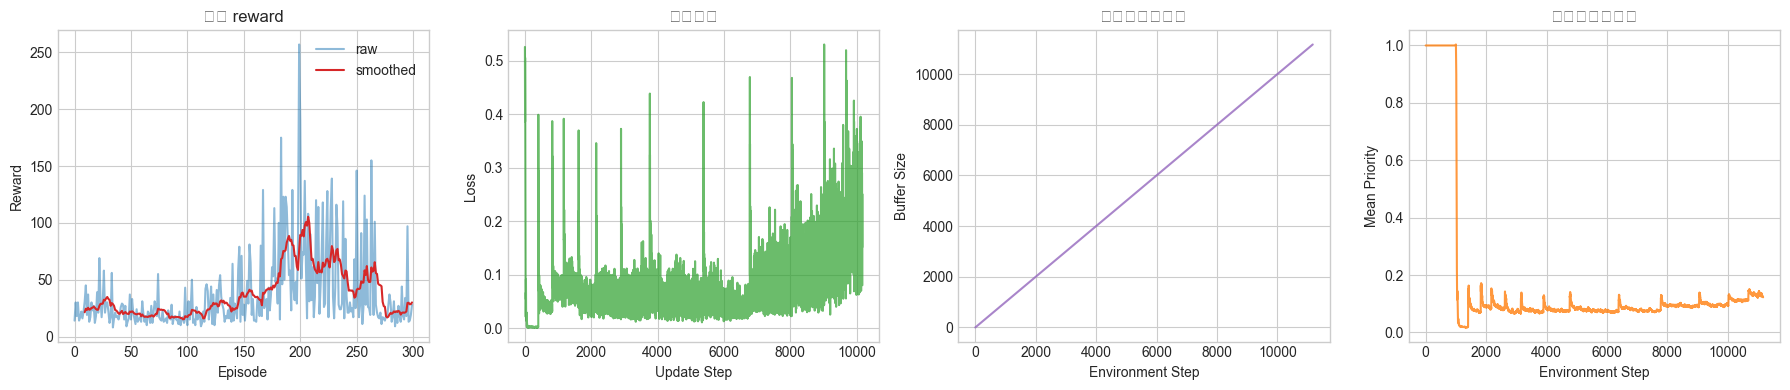

In [8]:
window = 10
smoothed_rewards = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(episode_rewards, color='#1f77b4', alpha=0.5, label='raw')
axes[0].plot(range(window - 1, len(episode_rewards)), smoothed_rewards, color='#d62728', label='smoothed')
axes[0].set_title('每轮 reward')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].legend()

axes[1].plot(loss_history, color='#2ca02c', alpha=0.7)
axes[1].set_title('训练损失')
axes[1].set_xlabel('Update Step')
axes[1].set_ylabel('Loss')

axes[2].plot(buffer_sizes, color='#9467bd', alpha=0.8)
axes[2].set_title('经验池大小变化')
axes[2].set_xlabel('Environment Step')
axes[2].set_ylabel('Buffer Size')

axes[3].plot(priority_means, color='#ff7f0e', alpha=0.8)
axes[3].set_title('平均优先级变化')
axes[3].set_xlabel('Environment Step')
axes[3].set_ylabel('Mean Priority')

plt.tight_layout()
plt.show()


## 7. 多次测试平均表现

我们继续测 5 次并看平均 reward，避免只看单次表现。


In [9]:
test_env = gym.make('CartPole-v1')
test_rewards = []

q_net.eval()
with torch.no_grad():
    for episode_idx in range(5):
        state, info = test_env.reset(seed=123 + episode_idx)
        test_reward = 0.0
        for step in range(500):
            state_tensor = to_tensor(state, device).unsqueeze(0)
            action = int(torch.argmax(q_net(state_tensor), dim=1).item())
            state, reward, terminated, truncated, info = test_env.step(action)
            test_reward += reward
            if terminated or truncated:
                break
        test_rewards.append(test_reward)

print('测试 rewards:', test_rewards)
print('测试平均 reward:', round(float(np.mean(test_rewards)), 2))
test_env.close()


测试 rewards: [98.0, 88.0, 95.0, 97.0, 97.0]
测试平均 reward: 95.0


## 8. 这节课最值得记住什么

如果你想抓住这节课的主线，就记住下面这张“职责分工图”：

- `Dueling DQN`：负责把价值表示学得更合理
- `Double DQN`：负责减少 Q 值高估
- `Prioritized Replay`：负责让训练样本更高效

它们不是重复做同一件事，而是在不同层面一起帮 DQN 变强。


## 9. 下一课最自然学什么

学完这一课后，下一步最自然的方向通常有两个：
- 正式进入 `Policy Gradient`
- 或继续扩展值函数路线，比如 Actor-Critic

如果按学习节奏来说，我最推荐你下一课开始上 `Policy Gradient / REINFORCE`。
